# v2 5-class confidence -> DCASE baseline

Fixed protocol: split the full baseline dataset into `train_pool 80%` and `final_test 20%` first. The confidence score is merged only into `train_pool`; `final_test` is never filtered and is used only for final evaluation.

This notebook uses `outputs/confidence_model_v2/predictions/BSD10k_oof_predicted_v2.csv` and creates three downstream training sets: predicted confidence `>= 2`, `>= 3`, and `>= 4`.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if not (HERE / 'confidence_baseline_common.py').exists():
    sys.path.insert(0, str(HERE / 'baseline_confidnce_train'))
else:
    sys.path.insert(0, str(HERE))

from confidence_baseline_common import ROOT, load_prediction_csv, run_downstream_grid, confidence_threshold_specs, load_baseline_assets, make_fixed_holdout

SEED = 1821
BASELINE_MODES = ('both',)
USE_KFOLD = True
N_FOLDS = 5
NUM_EPOCHS = 100
BATCH_SIZE = 64

OUTPUT_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v2_5class'
full_df, _, _ = load_baseline_assets(ROOT)
train_pool, final_test, _ = make_fixed_holdout(full_df, OUTPUT_ROOT, seed=SEED)

score_df = load_prediction_csv(ROOT / 'outputs' / 'confidence_model_v2' / 'predictions' / 'BSD10k_oof_predicted_v2.csv')
score_df = score_df[score_df['sound_id'].isin(set(train_pool['index'].astype(str)))].copy()
score_df = score_df[['sound_id', 'predicted_confidence_score', 'predicted_confidence_class', 'prob_confidence_1', 'prob_confidence_2', 'prob_confidence_3', 'prob_confidence_4', 'prob_confidence_5']].copy()
score_df.head()

,sound_id,predicted_confidence_score,predicted_confidence_class,prob_confidence_1,prob_confidence_2,prob_confidence_3,prob_confidence_4,prob_confidence_5
0,185755,3.230088,3,0.010525,0.083144,0.573375,0.331631,0.001325
3,432206,3.744333,4,0.000714,0.001820,0.252529,0.742291,0.002645
4,80630,4.095646,4,0.000565,0.000965,0.031638,0.835923,0.130909
6,145544,3.279489,3,0.027692,0.101732,0.446103,0.412342,0.012131
7,156796,3.517829,4,0.006529,0.113994,0.243808,0.626456,0.009212


In [2]:
summary, filter_counts = run_downstream_grid(
    experiment_name='v2_5class_expected_score',
    score_df=score_df,
    output_root=OUTPUT_ROOT,
    score_col='predicted_confidence_score',
    threshold_specs=confidence_threshold_specs([2, 3, 4]),
    baseline_modes=BASELINE_MODES,
    use_kfold=USE_KFOLD,
    n_folds=N_FOLDS,
    seed=SEED,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
)
display(filter_counts)
summary


=== Filter counts ===
filter_label               score_column  threshold  display_threshold  train_pool_samples  retained_samples  dropped_samples  retained_ratio  num_classes_retained
   pred_ge_2 predicted_confidence_score        2.0                  2                8764              8761                3        0.999658                    23
   pred_ge_3 predicted_confidence_score        3.0                  3                8764              8175              589        0.932793                    23
   pred_ge_4 predicted_confidence_score        4.0                  4                8764              1402             7362        0.159973                    16
Epoch [1/100] - Val acc: 59.56%
  New best model saved
Epoch [2/100] - Val acc: 70.62%
  New best model saved
Epoch [3/100] - Val acc: 72.22%
  New best model saved
Epoch [4/100] - Val acc: 75.87%
  New best model saved
Epoch [5/100] - Val acc: 77.98%
  New best model saved
Epoch [6/100] - Val acc: 78.09%
  New best model s

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.29%
[BaseClassifier | Fold final_test] Top class accuracy: 88.73%
[BaseClassifier | Fold final_test] Macro accuracy: 73.87%
[BaseClassifier | Fold final_test] Macro top class accuracy: 83.55%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 78.71%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.34%
[BaseClassifier | Fold final_test] Hierarchical recall: 77.50%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.04%
Epoch [1/100] - Val acc: 53.31%
  New best model saved
Epoch [2/100] - Val acc: 67.81%
  New best model saved
Epoch [3/100] - Val acc: 73.23%
  New best model saved
Epoch [4/100] - Val acc: 75.97%
  New best model saved
Epoch [5/100] - Val acc: 75.91%
Epoch [6/100] - Val acc: 78.60%
  New best model saved
Epoch [7/100] - Val acc: 78.82%
  New best model saved
Epoch [8/100] - Val acc: 78.71%
Epoch [9/100] - Val acc: 79.91%
  New best model saved
Epoch [10/100] - Val acc: 78.54%
Epoch [11/100] - Val acc:

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 81.43%
[BaseClassifier | Fold final_test] Top class accuracy: 89.37%
[BaseClassifier | Fold final_test] Macro accuracy: 76.35%
[BaseClassifier | Fold final_test] Macro top class accuracy: 85.61%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 80.98%
[BaseClassifier | Fold final_test] Hierarchical precision: 81.41%
[BaseClassifier | Fold final_test] Hierarchical recall: 79.82%
[BaseClassifier | Fold final_test] Hierarchical F1: 80.28%
Epoch [1/100] - Val acc: 53.71%
  New best model saved
Epoch [2/100] - Val acc: 65.18%
  New best model saved
Epoch [3/100] - Val acc: 71.69%
  New best model saved
Epoch [4/100] - Val acc: 74.26%
  New best model saved
Epoch [5/100] - Val acc: 75.46%
  New best model saved
Epoch [6/100] - Val acc: 76.20%
  New best model saved
Epoch [7/100] - Val acc: 76.88%
  New best model saved
Epoch [8/100] - Val acc: 76.88%
Epoch [9/100] - Val acc: 78.03%
  New best model saved
Epoch [10/100] - Val acc: 77.05%
Ep

...

[BaseClassifier | Fold final_test] Accuracy: 38.69%
[BaseClassifier | Fold final_test] Top class accuracy: 63.73%
[BaseClassifier | Fold final_test] Macro accuracy: 33.06%
[BaseClassifier | Fold final_test] Macro top class accuracy: 59.47%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 46.27%
[BaseClassifier | Fold final_test] Hierarchical precision: 54.16%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.75%
[BaseClassifier | Fold final_test] Hierarchical F1: 59.78%
Epoch [1/100] - Val acc: 30.00%
  New best model saved
Epoch [2/100] - Val acc: 83.93%
  New best model saved
Epoch [3/100] - Val acc: 95.00%
  New best model saved
Epoch [4/100] - Val acc: 95.71%
  New best model saved
Epoch [5/100] - Val acc: 95.00%
Epoch [6/100] - Val acc: 95.36%
Epoch [7/100] - Val acc: 95.36%
Epoch [8/100] - Val acc: 96.07%
  New best model saved
Epoch [9/100] - Val acc: 96.07%
Epoch [10/100] - Val acc: 96.07%
Epoch [11/100] - Val acc: 96.07%
Epoch [12/100] - Val acc: 97.14%
  New

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 34.63%
[BaseClassifier | Fold final_test] Top class accuracy: 60.13%
[BaseClassifier | Fold final_test] Macro accuracy: 29.73%
[BaseClassifier | Fold final_test] Macro top class accuracy: 54.15%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 41.94%
[BaseClassifier | Fold final_test] Hierarchical precision: 45.98%
[BaseClassifier | Fold final_test] Hierarchical recall: 68.53%
[BaseClassifier | Fold final_test] Hierarchical F1: 53.48%


,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,dropped_samples,retained_ratio,num_classes_retained
0,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,3,0.999658,23
1,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,589,0.932793,23
2,pred_ge_4,predicted_confidence_score,4.0,4,8764,1402,7362,0.159973,16


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
0,v2_5class_expected_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,0.999658,2192,ok,...,80.490588,80.291971,88.731752,73.866521,83.554865,78.710693,79.336662,77.499650,78.035835,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v2_5class_expected_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,0.999658,2192,ok,...,80.707763,81.432482,89.370438,76.347357,85.614875,80.981116,81.405732,79.822676,80.283042,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v2_5class_expected_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,0.999658,2192,ok,...,79.680365,80.976277,88.959854,74.351034,84.302589,79.326811,80.071493,78.082867,78.561260,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v2_5class_expected_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,0.999658,2192,ok,...,79.509132,80.246350,89.370438,74.372522,85.096648,79.734585,79.495193,78.394070,78.319538,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,v2_5class_expected_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,0.999658,2192,ok,...,80.079909,81.158759,89.872263,76.590134,86.567638,81.578886,80.606764,80.331698,80.317053,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,v2_5class_expected_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,0.932793,2192,ok,...,79.877676,79.151460,88.412409,73.318280,84.080733,78.699507,77.761874,77.354200,76.850097,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,v2_5class_expected_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,0.932793,2192,ok,...,81.467890,80.155109,88.549270,74.004014,84.186646,79.095330,78.418622,77.822501,77.870505,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,v2_5class_expected_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,0.932793,2192,ok,...,81.406728,80.291971,89.461679,74.785005,85.202419,79.993712,79.166244,78.691536,78.617276,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,v2_5class_expected_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,0.932793,2192,ok,...,81.651376,79.607664,88.914234,73.358282,85.194919,79.276600,79.704839,77.797021,78.239706,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v2_5class_expected_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,0.932793,2192,ok,...,80.978593,79.014599,89.005474,71.965752,84.142096,78.053924,79.049275,76.531881,77.182336,c:\Users\solok\Desktop\Dcase baseline\baseline...



=== All downstream run results ===
source: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v2_5class\summary_results.csv
saved view: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v2_5class\all_run_results_view.csv
filter_label  threshold  retained_samples  retained_ratio mode  split  train_samples  val_samples  final_test_samples  best_val_accuracy  accuracy  top_accuracy  macro_accuracy  hierarchical_accuracy  hierarchical_precision  hierarchical_recall  hierarchical_f1                                                                                             output_dir
   pred_ge_2        2.0              8761        0.999658 both fold_4           7009         1752                2192          80.079909 81.158759     89.872263       76.590134              81.578886               80.606764            80.331698        80.317053 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v2_5class\pred_ge_2\both\fold_4
   pred

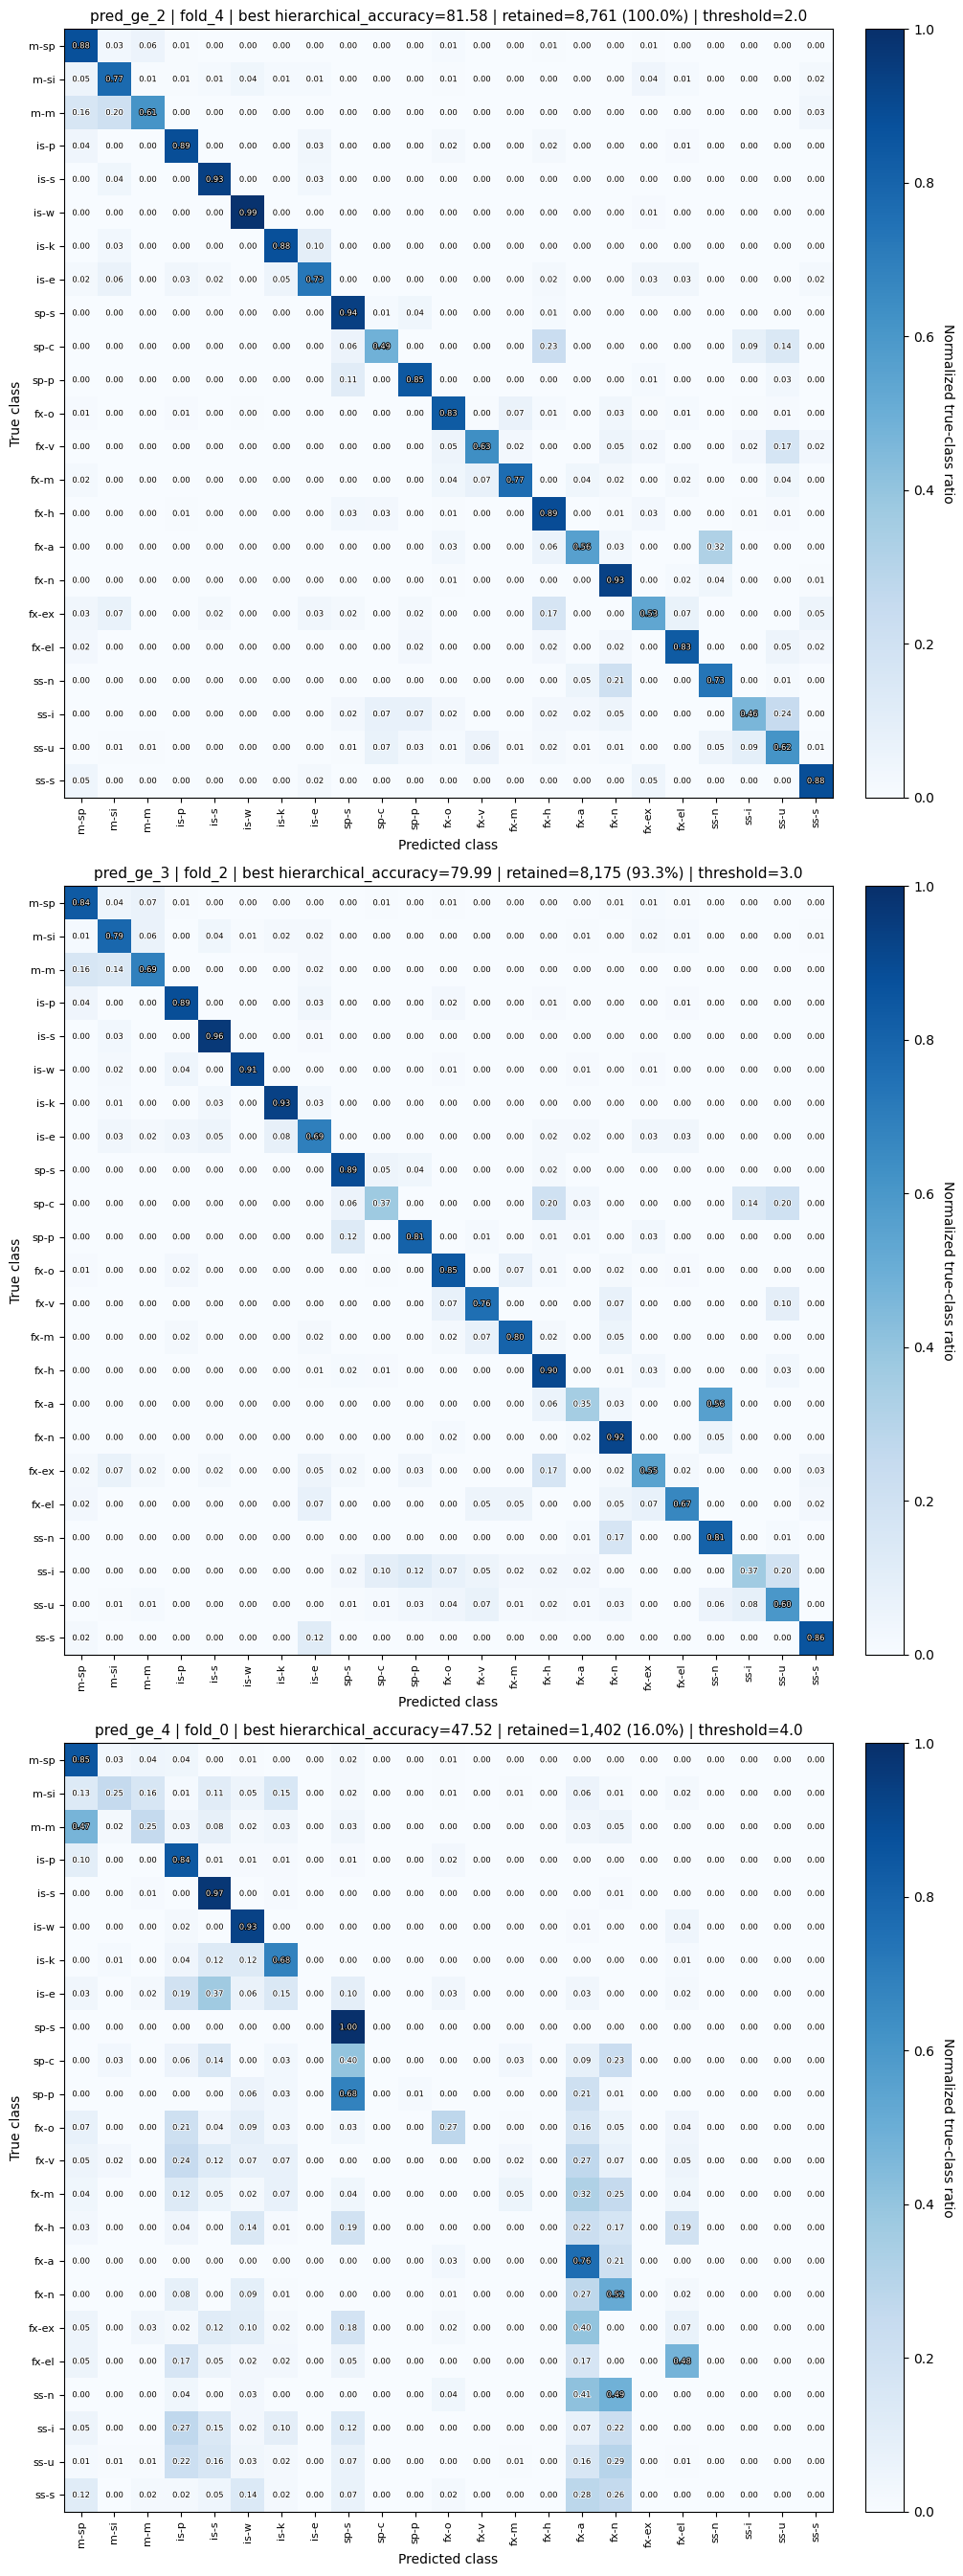


=== Best folds selected for confusion matrix ===
filter_label  threshold mode  split  retained_samples  retained_ratio  best_val_accuracy  accuracy  hierarchical_f1                                                                                             output_dir
   pred_ge_2        2.0 both fold_4              8761        0.999658          80.079909 81.158759        80.317053 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v2_5class\pred_ge_2\both\fold_4
   pred_ge_3        3.0 both fold_2              8175        0.932793          81.406728 80.291971        78.617276 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v2_5class\pred_ge_3\both\fold_2
   pred_ge_4        4.0 both fold_0              1402        0.159973          98.576512 39.872263        54.425430 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v2_5class\pred_ge_4\both\fold_0

saved best-fold table: c:\Users\solok\Desktop\Dcase baseline\baseline_con

,filter_label,threshold,retained_samples,retained_ratio,mode,split,train_samples,val_samples,final_test_samples,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
4,pred_ge_2,2.0,8761,0.999658,both,fold_4,7009,1752,2192,80.079909,81.158759,89.872263,76.590134,81.578886,80.606764,80.331698,80.317053,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,pred_ge_2,2.0,8761,0.999658,both,fold_1,7009,1752,2192,80.707763,81.432482,89.370438,76.347357,80.981116,81.405732,79.822676,80.283042,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,pred_ge_3,3.0,8175,0.932793,both,fold_2,6540,1635,2192,81.406728,80.291971,89.461679,74.785005,79.993712,79.166244,78.691536,78.617276,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,pred_ge_2,2.0,8761,0.999658,both,fold_3,7009,1752,2192,79.509132,80.246350,89.370438,74.372522,79.734585,79.495193,78.394070,78.319538,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,pred_ge_2,2.0,8761,0.999658,both,fold_2,7009,1752,2192,79.680365,80.976277,88.959854,74.351034,79.326811,80.071493,78.082867,78.561260,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,pred_ge_3,3.0,8175,0.932793,both,fold_3,6540,1635,2192,81.651376,79.607664,88.914234,73.358282,79.276600,79.704839,77.797021,78.239706,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,pred_ge_3,3.0,8175,0.932793,both,fold_1,6540,1635,2192,81.467890,80.155109,88.549270,74.004014,79.095330,78.418622,77.822501,77.870505,c:\Users\solok\Desktop\Dcase baseline\baseline...
0,pred_ge_2,2.0,8761,0.999658,both,fold_0,7008,1753,2192,80.490588,80.291971,88.731752,73.866521,78.710693,79.336662,77.499650,78.035835,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,pred_ge_3,3.0,8175,0.932793,both,fold_0,6540,1635,2192,79.877676,79.151460,88.412409,73.318280,78.699507,77.761874,77.354200,76.850097,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,pred_ge_3,3.0,8175,0.932793,both,fold_4,6540,1635,2192,80.978593,79.014599,89.005474,71.965752,78.053924,79.049275,76.531881,77.182336,c:\Users\solok\Desktop\Dcase baseline\baseline...


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir,fold_num
0,v2_5class_expected_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8761,0.999658,2192,ok,...,81.158759,89.872263,76.590134,86.567638,81.578886,80.606764,80.331698,80.317053,c:\Users\solok\Desktop\Dcase baseline\baseline...,4.0
1,v2_5class_expected_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8175,0.932793,2192,ok,...,80.291971,89.461679,74.785005,85.202419,79.993712,79.166244,78.691536,78.617276,c:\Users\solok\Desktop\Dcase baseline\baseline...,2.0
2,v2_5class_expected_score,pred_ge_4,predicted_confidence_score,4.0,4,8764,1402,0.159973,2192,ok,...,39.872263,64.096715,34.263575,60.768868,47.516222,56.547944,65.502948,54.425430,c:\Users\solok\Desktop\Dcase baseline\baseline...,0.0


WindowsPath('c:/Users/solok/Desktop/Dcase baseline/baseline_confidnce_train/outputs/v2_5class/best_fold_confusion_matrices_by_hierarchical_accuracy.png')

In [3]:
from pathlib import Path
import sys
import importlib

ROOT = Path(r"C:\Users\solok\Desktop\Dcase baseline")
sys.path.insert(0, str(ROOT))

import baseline_confidnce_train.confidence_baseline_common as cbc
importlib.reload(cbc)

all_results, best_folds, fig_path = cbc.show_v2_5class_results()
display(all_results)
display(best_folds)
fig_path